# A/B Testing Experiment Design: Sample Size, MDE, and Runtime Planning

This notebook is a tutorial-style companion to `AB_testing.ipynb`.
Instead of asking whether a finished experiment is statistically significant, we work backward from the design question:
**how much traffic do we need, how long should the test run, and what effect size can we realistically detect?**

We use the same e-commerce dataset and the same cleaning logic as the original notebook so the two analyses stay consistent.


In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Match the visual style across charts so the notebook reads like one story.
sns.set_theme(style="whitegrid", palette="crest")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## 1. Load the Dataset

We start with the raw experiment log and inspect the structure before cleaning.


In [2]:
# Load the raw event log that powers the rest of the notebook.
raw_df = pd.read_csv("data/ab_data.csv")

# Show the overall scale of the dataset before any filtering.
print(f"Raw rows: {raw_df.shape[0]:,}")
print(f"Unique users before cleaning: {raw_df['user_id'].nunique():,}")

# Preview the raw columns and the first few observations.
raw_df.head()

Raw rows: 294,478
Unique users before cleaning: 290,584


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


## 2. Clean the Data Using the Same Logic as the Original Notebook

To keep this notebook aligned with `AB_testing.ipynb`, we:

- remove users exposed to conflicting groups or landing pages
- keep only the first exposure per user
- parse timestamps and build daily traffic summaries


In [3]:
# Find users who appeared in more than one experiment group.
users_both_groups = raw_df.groupby("user_id")["group"].nunique()
users_both_groups = users_both_groups[users_both_groups > 1].index

# Find users who saw more than one landing page.
users_both_pages = raw_df.groupby("user_id")["landing_page"].nunique()
users_both_pages = users_both_pages[users_both_pages > 1].index

# A contaminated user is someone whose assignment was inconsistent.
contaminated_users = set(users_both_groups) | set(users_both_pages)

# Remove contaminated users, then keep only each user's first valid exposure.
df = raw_df[~raw_df["user_id"].isin(contaminated_users)].copy()
first_exposure = df.groupby("user_id")["timestamp"].min().reset_index()
df = df.merge(first_exposure, on=["user_id", "timestamp"])
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Build a daily traffic table that we will later use for runtime estimates.
daily_traffic = (
    df.groupby(df["timestamp"].dt.date)
    .size()
    .rename("users")
    .reset_index()
    .rename(columns={"timestamp": "date"})
)

# Summarize how much data remains after cleaning.
cleaning_summary = pd.DataFrame(
    {
        "metric": [
            "raw rows",
            "raw unique users",
            "contaminated users removed",
            "clean rows",
            "clean unique users",
            "experiment days observed",
        ],
        "value": [
            raw_df.shape[0],
            raw_df["user_id"].nunique(),
            len(contaminated_users),
            df.shape[0],
            df["user_id"].nunique(),
            daily_traffic.shape[0],
        ],
    }
)

display(cleaning_summary)
daily_traffic.head()

,metric,value
0,raw rows,294478
1,raw unique users,290584
2,contaminated users removed,3893
3,clean rows,286691
4,clean unique users,286691
5,experiment days observed,23


,date,users
0,2017-01-02,5631
1,2017-01-03,13025
2,2017-01-04,12929
3,2017-01-05,12748
4,2017-01-06,13168


The cleaned dataset is the right input for planning because it reflects the traffic that reached a valid experimental condition.


,metric,value
0,average daily users,12464.83
1,median daily users,13013.00
2,minimum daily users,5631.00
3,maximum daily users,13231.00
4,average daily users per variant (50/50 split),6232.41


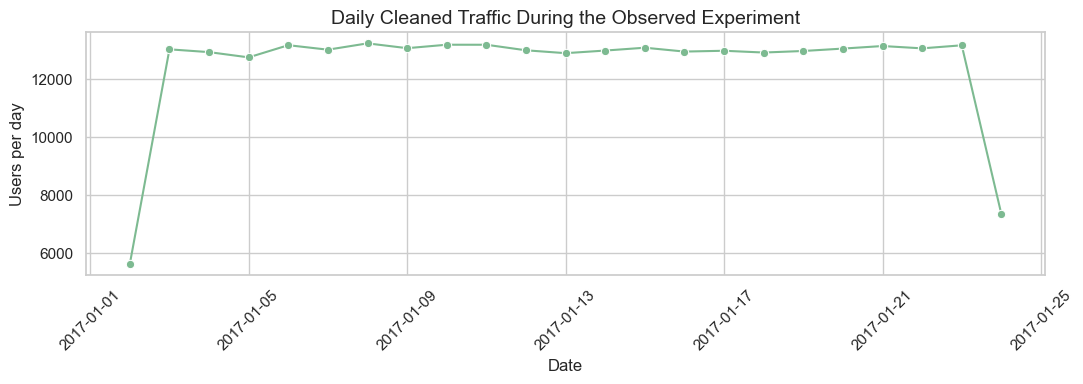

In [4]:
# Summarize daily traffic because test duration depends on traffic volume.
traffic_summary = pd.DataFrame(
    {
        "metric": [
            "average daily users",
            "median daily users",
            "minimum daily users",
            "maximum daily users",
            "average daily users per variant (50/50 split)",
        ],
        "value": [
            daily_traffic["users"].mean(),
            daily_traffic["users"].median(),
            daily_traffic["users"].min(),
            daily_traffic["users"].max(),
            daily_traffic["users"].mean() / 2,
        ],
    }
)

display(traffic_summary.round(2))

# Visualize how stable the cleaned daily traffic was across the experiment window.
plt.figure(figsize=(11, 4))
sns.lineplot(data=daily_traffic, x="date", y="users", marker="o")
plt.title("Daily Cleaned Traffic During the Observed Experiment")
plt.xlabel("Date")
plt.ylabel("Users per day")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Estimate the Baseline Conversion Rate

Sample-size calculations need a baseline conversion rate. We use the cleaned control-group conversion rate because it represents the current page performance.


In [5]:
# Split the cleaned data by variant so we can compare current performance.
control_df = df[df["group"] == "control"].copy()
treatment_df = df[df["group"] == "treatment"].copy()

# The control conversion rate is our planning baseline.
baseline_rate = control_df["converted"].mean()
treatment_rate = treatment_df["converted"].mean()
observed_relative_gap = (treatment_rate - baseline_rate) / baseline_rate
avg_daily_total = daily_traffic["users"].mean()
avg_daily_per_variant = avg_daily_total / 2

# Collect the key planning inputs in one small summary table.
baseline_summary = pd.DataFrame(
    {
        "metric": [
            "control conversion rate (baseline)",
            "treatment conversion rate",
            "observed relative lift vs baseline",
            "average daily traffic",
            "average daily traffic per variant",
        ],
        "value": [
            baseline_rate,
            treatment_rate,
            observed_relative_gap,
            avg_daily_total,
            avg_daily_per_variant,
        ],
    }
)

display(
    baseline_summary.assign(
        value=[
            f"{baseline_rate:.2%}",
            f"{treatment_rate:.2%}",
            f"{observed_relative_gap:.2%}",
            f"{avg_daily_total:,.0f}",
            f"{avg_daily_per_variant:,.0f}",
        ]
    )
)

,metric,value
0,control conversion rate (baseline),12.02%
1,treatment conversion rate,11.87%
2,observed relative lift vs baseline,-1.20%
3,average daily traffic,"12,465"
4,average daily traffic per variant,"6,232"


## 4. Build Sample-Size and Runtime Helpers

We assume a standard fixed-horizon experiment design:

- two-sided test
- significance level `alpha = 0.05`
- target power `0.80`
- 50/50 traffic allocation between control and treatment

The helpers below convert between business goals and experiment requirements.


In [6]:
power_model = NormalIndPower()


def required_sample_size_per_variant(
    baseline_rate: float,
    relative_lift: float,
    alpha: float = 0.05,
    power: float = 0.80,
) -> int:
    """Return the required sample size per variant for a target relative lift."""
    target_rate = baseline_rate * (1 + relative_lift)
    effect_size = proportion_effectsize(target_rate, baseline_rate)
    required_n = power_model.solve_power(
        effect_size=effect_size,
        power=power,
        alpha=alpha,
        ratio=1.0,
        alternative="two-sided",
    )
    return math.ceil(required_n)


def runtime_days(
    sample_size_per_variant: int,
    avg_daily_total: float,
    traffic_split: float = 0.5,
) -> float:
    """Translate a sample-size requirement into expected calendar days."""
    daily_users_per_variant = avg_daily_total * traffic_split
    return sample_size_per_variant / daily_users_per_variant


def detectable_relative_lift(
    baseline_rate: float,
    sample_size_per_variant: int,
    alpha: float = 0.05,
    power: float = 0.80,
) -> float:
    """Approximate the smallest relative lift detectable with the available sample."""
    required_effect = power_model.solve_power(
        effect_size=None,
        nobs1=sample_size_per_variant,
        power=power,
        alpha=alpha,
        ratio=1.0,
        alternative="two-sided",
    )

    # Search over plausible conversion rates until the implied effect size matches
    # the minimum effect required for the chosen sample size, alpha, and power.
    low = baseline_rate
    high = min(0.50, baseline_rate + 0.10)

    for _ in range(80):
        mid = (low + high) / 2
        effect_size = abs(proportion_effectsize(mid, baseline_rate))
        if effect_size < required_effect:
            low = mid
        else:
            high = mid

    target_rate = (low + high) / 2
    return (target_rate - baseline_rate) / baseline_rate

## 5. Calculate Sample-Size Scenarios for Common Lift Targets

Product teams often reason in terms of relative lift, so we will test three planning scenarios: **0.5%**, **1%**, and **2%** relative improvement over baseline.


In [7]:
# These are the headline lift targets we want to evaluate.
planning_lifts = [0.005, 0.01, 0.02]

# Build a planning table that ties each lift target to traffic and time.
scenario_rows = []
for relative_lift in planning_lifts:
    target_rate = baseline_rate * (1 + relative_lift)
    sample_size = required_sample_size_per_variant(baseline_rate, relative_lift)
    expected_days = runtime_days(sample_size, avg_daily_total)
    scenario_rows.append(
        {
            "target_relative_lift": relative_lift,
            "target_conversion_rate": target_rate,
            "required_users_per_variant": sample_size,
            "total_users_required": sample_size * 2,
            "estimated_runtime_days": expected_days,
        }
    )

scenario_df = pd.DataFrame(scenario_rows)

display(
    scenario_df.assign(
        target_relative_lift=scenario_df["target_relative_lift"].map(
            lambda x: f"{x:.1%}"
        ),
        target_conversion_rate=scenario_df["target_conversion_rate"].map(
            lambda x: f"{x:.2%}"
        ),
        required_users_per_variant=scenario_df["required_users_per_variant"].map(
            lambda x: f"{x:,.0f}"
        ),
        total_users_required=scenario_df["total_users_required"].map(
            lambda x: f"{x:,.0f}"
        ),
        estimated_runtime_days=scenario_df["estimated_runtime_days"].map(
            lambda x: f"{x:,.1f}"
        ),
    )
)

,target_relative_lift,target_conversion_rate,required_users_per_variant,total_users_required,estimated_runtime_days
0,0.5%,12.08%,"4,607,030","9,214,060",739.2
1,1.0%,12.14%,"1,154,231","2,308,462",185.2
2,2.0%,12.26%,"289,791","579,582",46.5


These numbers help translate a statistical goal into an operational plan. Small lift targets are much more expensive because the experiment must distinguish between very similar conversion rates.


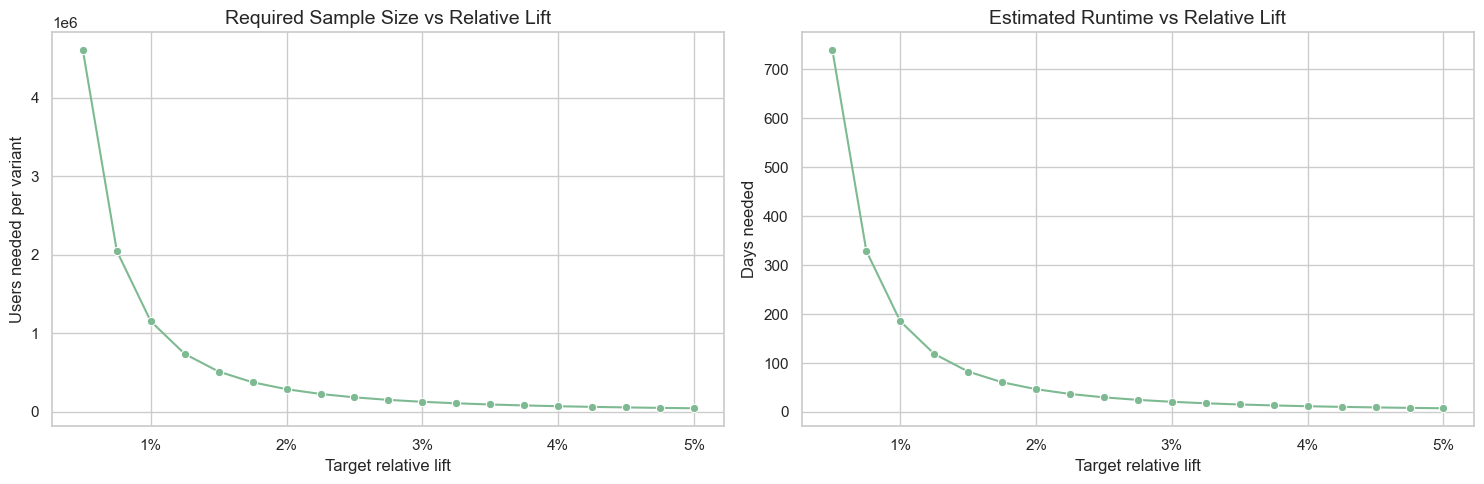

,relative_lift,required_users_per_variant,estimated_runtime_days
0,0.0050,4607030,739.204858
1,0.0075,2049768,328.888343
2,0.0100,1154231,185.198091
3,0.0125,739498,118.653561
4,0.0150,514088,82.486189
5,0.0175,378100,60.666711
6,0.0200,289791,46.497400
7,0.0225,229213,36.777569


In [8]:
# Sweep across a wider range of lift targets to see how requirements change.
lift_grid = np.arange(0.005, 0.0505, 0.0025)
sensitivity_df = pd.DataFrame(
    {
        "relative_lift": lift_grid,
        "required_users_per_variant": [
            required_sample_size_per_variant(baseline_rate, lift) for lift in lift_grid
        ],
    }
)

# Convert each sample-size requirement into a runtime estimate.
sensitivity_df["estimated_runtime_days"] = sensitivity_df[
    "required_users_per_variant"
].apply(lambda n: runtime_days(n, avg_daily_total))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: required users per variant as the lift target changes.
sns.lineplot(
    data=sensitivity_df,
    x="relative_lift",
    y="required_users_per_variant",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Required Sample Size vs Relative Lift")
axes[0].set_xlabel("Target relative lift")
axes[0].set_ylabel("Users needed per variant")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

# Plot 2: expected test duration for the same set of lift targets.
sns.lineplot(
    data=sensitivity_df,
    x="relative_lift",
    y="estimated_runtime_days",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Estimated Runtime vs Relative Lift")
axes[1].set_xlabel("Target relative lift")
axes[1].set_ylabel("Days needed")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

plt.tight_layout()
plt.show()

# Show the first few rows so the chart has a matching numeric table.
sensitivity_df.head(8)

## 6. Feasibility Check Using the Observed Experiment Traffic

Now we compare those planning targets to the traffic we actually observed in this dataset. This tells us whether the historical experiment window was large enough for different lift goals.


In [9]:
# Use the smaller arm size so the feasibility check is conservative.
observed_control_n = int((df["group"] == "control").sum())
observed_treatment_n = int((df["group"] == "treatment").sum())
observed_per_variant_n = min(observed_control_n, observed_treatment_n)

# Estimate the smallest lift this experiment size could realistically detect.
detectable_lift = detectable_relative_lift(baseline_rate, observed_per_variant_n)

# Compare the observed traffic with each planning scenario.
feasibility_df = scenario_df.copy()
feasibility_df["observed_users_per_variant"] = observed_per_variant_n
feasibility_df["enough_sample"] = (
    feasibility_df["observed_users_per_variant"]
    >= feasibility_df["required_users_per_variant"]
)
feasibility_df["traffic_gap_users_per_variant"] = (
    feasibility_df["required_users_per_variant"]
    - feasibility_df["observed_users_per_variant"]
).clip(lower=0)

display(
    feasibility_df.assign(
        target_relative_lift=feasibility_df["target_relative_lift"].map(
            lambda x: f"{x:.1%}"
        ),
        required_users_per_variant=feasibility_df["required_users_per_variant"].map(
            lambda x: f"{x:,.0f}"
        ),
        observed_users_per_variant=feasibility_df["observed_users_per_variant"].map(
            lambda x: f"{x:,.0f}"
        ),
        estimated_runtime_days=feasibility_df["estimated_runtime_days"].map(
            lambda x: f"{x:,.1f}"
        ),
        traffic_gap_users_per_variant=feasibility_df[
            "traffic_gap_users_per_variant"
        ].map(lambda x: f"{x:,.0f}"),
    )[
        [
            "target_relative_lift",
            "required_users_per_variant",
            "observed_users_per_variant",
            "estimated_runtime_days",
            "enough_sample",
            "traffic_gap_users_per_variant",
        ]
    ]
)

# Summarize the single most important feasibility takeaways.
feasibility_summary = pd.DataFrame(
    {
        "metric": [
            "observed users per variant",
            "observed experiment days",
            "approximate detectable relative lift at 80% power",
            "absolute lift implied by that MDE",
        ],
        "value": [
            f"{observed_per_variant_n:,.0f}",
            f"{daily_traffic.shape[0]}",
            f"{detectable_lift:.2%}",
            f"{baseline_rate * detectable_lift:.2%}",
        ],
    }
)
display(feasibility_summary)

,target_relative_lift,required_users_per_variant,observed_users_per_variant,estimated_runtime_days,enough_sample,traffic_gap_users_per_variant
0,0.5%,"4,607,030","143,293",739.2,False,"4,463,737"
1,1.0%,"1,154,231","143,293",185.2,False,"1,010,938"
2,2.0%,"289,791","143,293",46.5,False,"146,498"


,metric,value
0,observed users per variant,"143,293"
1,observed experiment days,23
2,approximate detectable relative lift at 80% power,2.85%
3,absolute lift implied by that MDE,0.34%


## 7. Final Recommendation

A useful recommendation should connect the statistical results to an action a product team can understand.


In [10]:
# Pull the headline scenarios into named variables for a readable recommendation.
two_percent_days = float(
    scenario_df.loc[
        scenario_df["target_relative_lift"] == 0.02, "estimated_runtime_days"
    ].iloc[0]
)
one_percent_days = float(
    scenario_df.loc[
        scenario_df["target_relative_lift"] == 0.01, "estimated_runtime_days"
    ].iloc[0]
)
half_percent_days = float(
    scenario_df.loc[
        scenario_df["target_relative_lift"] == 0.005, "estimated_runtime_days"
    ].iloc[0]
)

two_percent_users = int(
    scenario_df.loc[
        scenario_df["target_relative_lift"] == 0.02, "required_users_per_variant"
    ].iloc[0]
)
one_percent_users = int(
    scenario_df.loc[
        scenario_df["target_relative_lift"] == 0.01, "required_users_per_variant"
    ].iloc[0]
)
half_percent_users = int(
    scenario_df.loc[
        scenario_df["target_relative_lift"] == 0.005, "required_users_per_variant"
    ].iloc[0]
)

# Convert the notebook's numeric results into a business-friendly summary.
recommendation = f"""
### Recommendation

- The cleaned control conversion rate is **{baseline_rate:.2%}**, and the experiment delivered about **{avg_daily_total:,.0f} users/day** in total.
- With this traffic, a balanced two-arm test would get roughly **{avg_daily_per_variant:,.0f} users/day per variant**.
- Detecting a **2% relative lift** would require about **{two_percent_users:,} users per variant** and roughly **{two_percent_days:.1f} days** of runtime.
- Detecting a **1% relative lift** would require about **{one_percent_users:,} users per variant** and roughly **{one_percent_days:.1f} days**.
- Detecting a **0.5% relative lift** would require about **{half_percent_users:,} users per variant** and about **{half_percent_days:.1f} days**, which is not realistic for this traffic level.
- The observed dataset contains about **{observed_per_variant_n:,} users per variant**, so this historical experiment was powered for effects of roughly **{detectable_lift:.2%} relative lift or larger**.

In plain English: if the business only cares about very small improvements around a 1% relative lift, this site needs a much longer experiment. If the business cares about lifts closer to **3% relative improvement or above**, the current traffic volume is much more realistic for a fixed-horizon A/B test.
"""

display(Markdown(recommendation))


### Recommendation

- The cleaned control conversion rate is **12.02%**, and the experiment delivered about **12,465 users/day** in total.
- With this traffic, a balanced two-arm test would get roughly **6,232 users/day per variant**.
- Detecting a **2% relative lift** would require about **289,791 users per variant** and roughly **46.5 days** of runtime.
- Detecting a **1% relative lift** would require about **1,154,231 users per variant** and roughly **185.2 days**.
- Detecting a **0.5% relative lift** would require about **4,607,030 users per variant** and about **739.2 days**, which is not realistic for this traffic level.
- The observed dataset contains about **143,293 users per variant**, so this historical experiment was powered for effects of roughly **2.85% relative lift or larger**.

In plain English: if the business only cares about very small improvements around a 1% relative lift, this site needs a much longer experiment. If the business cares about lifts closer to **3% relative improvement or above**, the current traffic volume is much more realistic for a fixed-horizon A/B test.
